In [1]:
from transformers import ViTModel, ViTConfig

input_size = TrainDataGenerator.CHANNELS_COUNT
num_classes = len(Elements.ELEMENT_LINES.keys())
num_channels = 2
num_kernels = 8
embed_dim = num_channels * num_kernels**2
patch_size = num_kernels
num_heads = 8
num_layers = 8
hidden_dim = 4 * embed_dim
dropout_rate = 0.05

class ViTWithCustomHead(nn.Module):
    def __init__(self, vit_model, num_classes, dropout=0.5):
        super(ViTWithCustomHead, self).__init__()
        self.vit = vit_model  # The ViT backbone
        self.custom_head = nn.Sequential(
            nn.Linear(self.vit.config.hidden_size, self.vit.config.intermediate_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.vit.config.intermediate_size, num_classes)
        )

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_output = outputs.pooler_output
        logits = self.custom_head(cls_output)
        return logits


vit_config = ViTConfig(hidden_size=embed_dim
                       , intermediate_size=hidden_dim
                       , num_channels=num_channels
                       , image_size=(num_kernels, input_size)
                       , patch_size=num_kernels
                       , encoder_stride=num_kernels
                       , num_attention_heads=num_heads
                       , num_hidden_layers=num_layers
                       , attention_probs_dropout_prob=dropout_rate
                       , hidden_dropout_prob=dropout_rate)
model = ViTWithCustomHead(ViTModel(vit_config), num_classes).to(DEVICE)


pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

graph = draw_graph(model, input_size=(16, 2, 8, 4096), expand_nested=True, depth=2)
graphviz.set_jupyter_format('png')
graph.visual_graph

/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'TrainDataGenerator' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import graphviz 
from torchview import draw_graph

from src.Elements import Elements

class ResidualConvBlock(nn.Module):
    def __init__(self, out_channels, downsample=False):
        super().__init__()
        self.conv1 = nn.LazyConv1d(out_channels, kernel_size=1)
        self.bn2 = nn.LazyBatchNorm1d()
        self.bn1 = nn.LazyBatchNorm1d()

        if downsample:
            self.conv2 = nn.LazyConv1d(out_channels, kernel_size=3, stride=2, padding=1)
            self.skip = nn.Sequential(*[nn.AvgPool1d(2), nn.LazyConv1d(out_channels, kernel_size=1)])
        else:
            self.conv2 = nn.LazyConv1d(out_channels, kernel_size=3, stride=1, padding=1)
            self.skip = nn.Identity() 

            
    def forward(self, x):
        Y = F.relu(self.bn1(self.conv1(x)))
        Y = self.bn2(self.conv2(Y))
        Y += self.skip(x)
        return F.relu(Y)

class ResNetResidualBlock(nn.Module):
    def __init__(self, num_residuals, num_channels, downsample=False):
        super().__init__()
        blk = []
        for i in range(num_residuals):
            if i == 0 and downsample:
                blk.append(ResidualConvBlock(num_channels, downsample=True))
            else:
                blk.append(ResidualConvBlock(num_channels))

        self.block = nn.Sequential(*blk)

    def forward(self, x):
        return self.block(x)

class ResidualConvTransposeBlock(nn.Module):
    """Residual Block with ConvTranspose1d for upsampling."""
    def __init__(self, out_channels, upsample=False):
        super().__init__()
        self.conv1 = nn.LazyConv1d(out_channels, kernel_size=1)
        self.bn1 = nn.LazyBatchNorm1d()
        self.bn2 = nn.LazyBatchNorm1d()

        if upsample:
            self.conv2 = nn.LazyConvTranspose1d(out_channels, kernel_size=3, stride=2, padding=1, output_padding=1)
            self.skip = nn.Sequential(
                nn.Upsample(scale_factor=2, mode="linear", align_corners=True),
                nn.LazyConv1d(out_channels, kernel_size=1)
            )
        else:
            self.conv2 = nn.LazyConv1d(out_channels, kernel_size=3, stride=1, padding=1)
            self.skip = nn.Identity()

    def forward(self, x):
        Y = F.relu(self.bn1(self.conv1(x)))
        Y = self.bn2(self.conv2(Y))
        Y += self.skip(x)
        return F.relu(Y)

class ResNetResidualTransposeBlock(nn.Module):
    """Stack of Residual Blocks with Upsampling."""
    def __init__(self, num_residuals, num_channels, upsample=False):
        super().__init__()
        blk = []
        for i in range(num_residuals):
            if i == 0 and upsample:
                blk.append(ResidualConvTransposeBlock(num_channels, upsample=True))
            else:
                blk.append(ResidualConvTransposeBlock(num_channels))

        self.block = nn.Sequential(*blk)

    def forward(self, x):
        return self.block(x)


class ResNetStemBlock(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.LazyConv1d(out_channels, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm1d(),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
    
    def forward(self, x):
        return self.block(x)

class XRFAutoencoder(nn.Module):
    def __init__(self, latent_dim=10, input_channels=1):
        super().__init__()
         
        # Encoder (Same as Before)
        self.encoder = nn.Sequential(
            ResNetStemBlock(64),
            *[ResNetResidualBlock(1, 64) for _ in range(2)],
            *[ResNetResidualBlock(2, 128 * 2**i, downsample=True) for i in range(2)],
            nn.LazyConv1d(latent_dim, 1)
        )

        # Classifiers for each latent dimension
        self.classifiers = nn.ModuleList([
            nn.Sequential(
                nn.LazyLinear(128),
                nn.ReLU(),
                nn.LazyLinear(128),
                nn.ReLU(),
                nn.LazyLinear(1),
                nn.Sigmoid()
            ) for _ in range(latent_dim)
        ])
        
        # Decoder (Mirrored Residual Blocks)
        self.decoder = nn.Sequential(
            nn.LazyConvTranspose1d(256, 1),
            *[ResNetResidualTransposeBlock(2, 128 * 2**i, upsample=True) for i in range(1, -1, -1)],
            *[ResNetResidualTransposeBlock(1, 64) for _ in range(2)],
            nn.LazyConvTranspose1d(input_channels, kernel_size=7, stride=1, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        
        # Classifier outputs
        z_prime = [self.classifiers[c](z[:, c, :].reshape(-1, z.shape[-1])) for c in range(z.shape[1])]
        z_prime = torch.stack(z_prime, axis=1).squeeze()

        # Decoder reconstructs input
        x_reconstructed = self.decoder(z)
        
        return z_prime, x_reconstructed
    
    def to(self, device):
        super().to(device)
        self.encoder.to(device)
        for classifier in self.classifiers:
            classifier.to(device)
        return self 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = XRFAutoencoder(latent_dim=len(Elements.LINES)).to(device)
# print()
model(torch.tensor([1.0]*4096 * 32).reshape(32, 1, -1).to(device))
a = 1
# pytorch_total_params = sum(p.numel() for p in model.parameters())
# print(pytorch_total_params)

# graph = draw_graph(model, input_size=(32, 1, 4096))
kkkkkkjj# graphviz.set_jupyter_format('png')

RuntimeError: The size of tensor a (64) must match the size of tensor b (128) at non-singleton dimension 1

In [ ]:
class XRF_Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(XRF_Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.LazyLinear(latent_dim),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Unflatten(1, (1, 256)),
            nn.LazyConv1d(256, 1),
            nn.ConvTranspose1d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        z = self.encoder(x)

        y = z.detach().clone()
        infinity_mask = (z > 0.5).bool()
        z[infinity_mask] = -torch.inf
        z = self.softmax(z)
        x_prime = self.decoder(z)
        return y, x_prime

model = XRF_Autoencoder(latent_dim=len(Elements.LINES)).to(device)
# print()
input = torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device)
# print(input.shape)
out = model(input)
# print(out.shape)
a = 1
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

393256


In [88]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/artificial/X.npy")
y = np.load("data/artificial/y.npy")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 64)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 64)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
def custom_criterion(y_pred, x_pred , y_batch, X_batch, alpha=0.5):
    mse_loss = criterion(y_pred, y_batch)
    x_mse_loss = criterion(x_pred, X_batch)
train_history, valid_history, best_loss, best_weights = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=10, mode="autoencoder")

Epoch 1/10
Batch 100, Loss: 0.0141
Batch 200, Loss: 0.0112
Batch 300, Loss: 0.0099
Batch 400, Loss: 0.0099
Batch 500, Loss: 0.0095
Batch 600, Loss: 0.0094
Batch 700, Loss: 0.0089
Batch 800, Loss: 0.0088
Batch 900, Loss: 0.0081
Batch 1000, Loss: 0.0081
Batch 1100, Loss: 0.0076
Batch 1200, Loss: 0.0081
Batch 1300, Loss: 0.0075
Batch 1400, Loss: 0.0068
Train Epoch Average Loss: 0.0098
Validation Loss: 0.0074
New best model saved.
Epoch 2/10
Batch 100, Loss: 0.0073
Batch 200, Loss: 0.0069
Batch 300, Loss: 0.0074
Batch 400, Loss: 0.0072
Batch 500, Loss: 0.0073
Batch 600, Loss: 0.0066
Batch 700, Loss: 0.0064
Batch 800, Loss: 0.0061
Batch 900, Loss: 0.0064
Batch 1000, Loss: 0.0066
Batch 1100, Loss: 0.0065
Batch 1200, Loss: 0.0060
Batch 1300, Loss: 0.0065
Batch 1400, Loss: 0.0062
Train Epoch Average Loss: 0.0066
Validation Loss: 0.0062
New best model saved.
Epoch 3/10
Batch 100, Loss: 0.0061
Batch 200, Loss: 0.0058
Batch 300, Loss: 0.0056
Batch 400, Loss: 0.0061
Batch 500, Loss: 0.0056
Batch 6

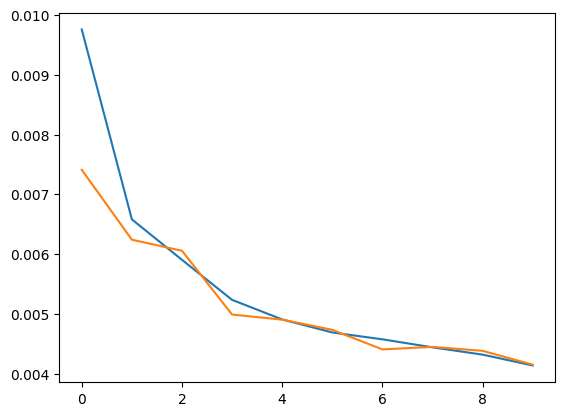

In [98]:
import matplotlib.pyplot as plt
plt.plot(train_history)
plt.plot(valid_history)


(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)
(4096,)


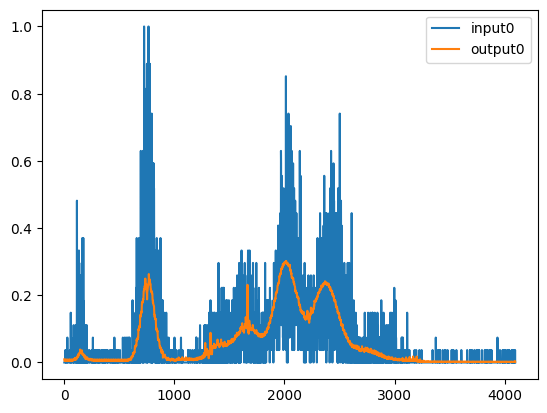

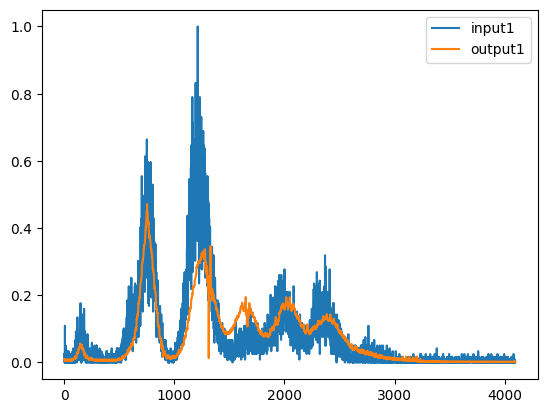

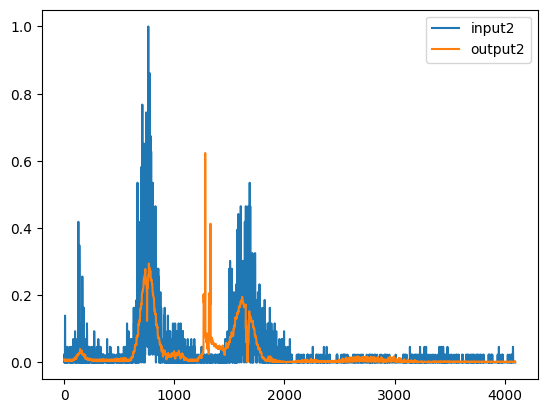

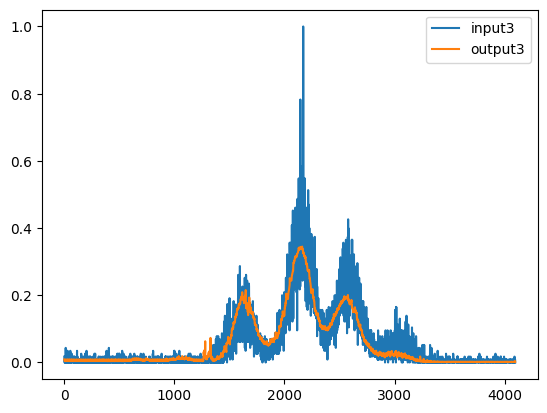

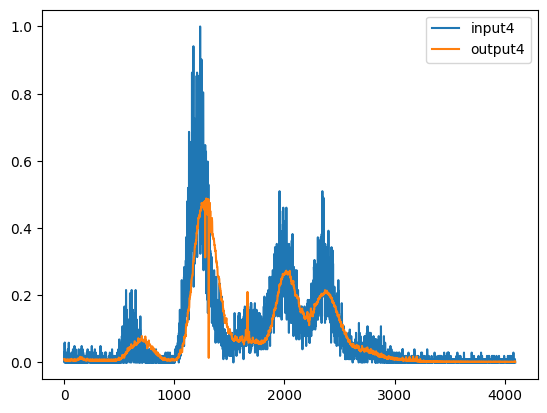

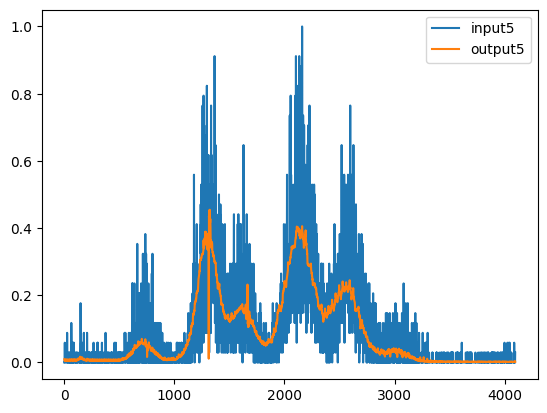

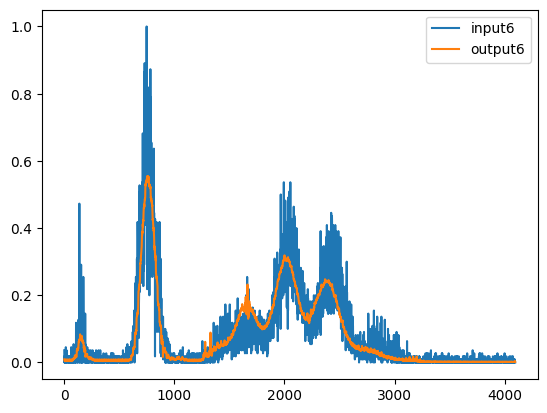

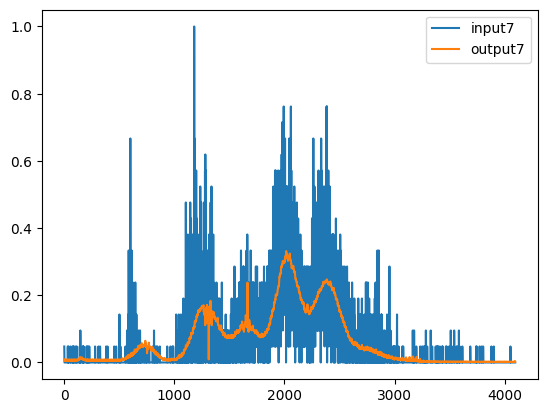

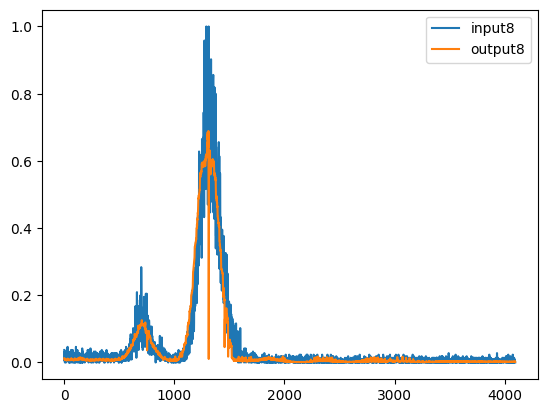

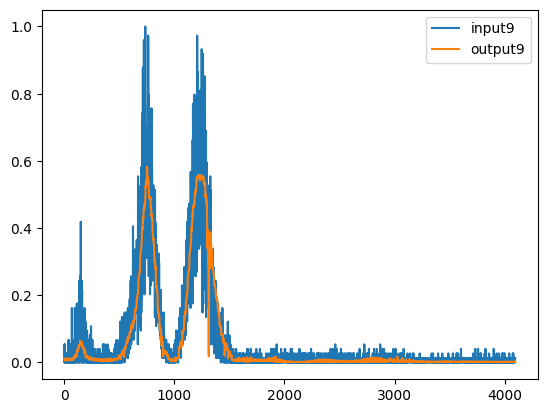

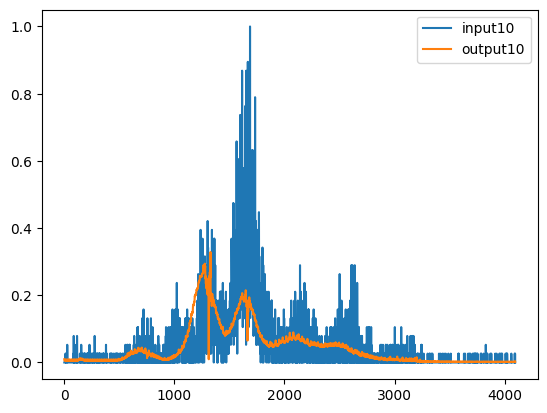

In [99]:
import matplotlib.pyplot as plt

for i, (X_batch, y_batch) in enumerate(trainloader):
    A = X_batch.cpu().squeeze().detach().numpy()[0]
    print(A.shape)
    B = model(X_batch).cpu().squeeze().detach().numpy()[0]
    print(B.shape)

    plt.figure(i)
    plt.plot(A, label=f"input{i}")
    plt.plot(B, label=f"output{i}")
    plt.legend()
    if i == 10:
        break

In [63]:
for x_batch, y_batch in testloader:
    print(np.abs(np.average((y_batch - model(x_batch)).cpu().detach().numpy()), axis=0))

TypeError: absolute() got an unexpected keyword argument 'axis'